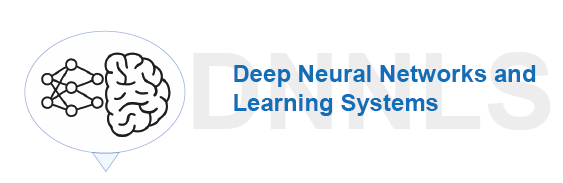

# Final assessment - Main Notebook
---

**Introduction:**

In this notebook you will find a baseline, functional architecture for your assessment task.

In [2]:
import gc
import os
import random
import re
import re
import textwrap
from typing import Dict, Any, List, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
# @title Importing the necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.transforms.functional as FT
from bs4 import BeautifulSoup
from datasets.fingerprint import random
from google.colab import drive
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import BertTokenizer
from google.colab import drive

from src.model import (EncoderLSTM, DecoderLSTM, Seq2SeqLSTM,
                        Backbone, VisualEncoder, VisualDecoder, VisualAutoencoder,
                        Attention, SequencePredictor,
                        ResNetVisualEncoder, ModifiedSequencePredictor)

from src.utils import (save_checkpoint_to_drive, load_checkpoint_from_drive,
                        parse_gdi_text, show_image, SequencePredictionDataset,
                        TextTaskDataset, AutoEncoderTaskDataset, init_weights,
                        generate, validation)
from src.train import train_model


In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# **Chapter 1: The data preparation**


---



First we need to activate our google drive so that we can save out data permanently.

## 1.1 Loading and saving data

Now we load dataset from HuggingFace:

In [4]:
# @title Loading the dataset
from datasets import load_dataset

train_dataset = load_dataset("daniel3303/StoryReasoning", split="train")
test_dataset = load_dataset("daniel3303/StoryReasoning", split="test")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/327M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3552 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/626 [00:00<?, ? examples/s]

In [5]:
# @title For the Sequence prediction task
"""
This cell sets up the data pipeline for the main sequence prediction task.
1. Initializes the BERT tokenizer.
2. Creates `SequencePredictionDataset` instances for training and testing.
3. Splits the training data into `train_subset` and `val_subset`.
4. Creates `DataLoader` objects (`train_dataloader`, `val_dataloader`, `test_dataloader`) to batch and shuffle the data.
"""

tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-uncased",  padding=True, truncation=True)
sp_train_dataset = SequencePredictionDataset(train_dataset, tokenizer) # Instantiate the train dataset
sp_test_dataset = SequencePredictionDataset(test_dataset, tokenizer) # Instantiate the test dataset

# Let's do things properly, we will also have a validation split
# Split the training dataset into training and validation sets
train_size = int(0.8 * len(sp_train_dataset))
val_size = len(sp_train_dataset) - train_size
train_subset, val_subset = random_split(sp_train_dataset, [train_size, val_size])

# Instantiate the dataloaders
train_dataloader = DataLoader(train_subset, batch_size=8, shuffle=True)
# We will use the validation set to visualize the progress.
val_dataloader = DataLoader(val_subset, batch_size=4, shuffle=True)
test_dataloader = DataLoader(sp_test_dataset, batch_size=4, shuffle=False)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
# @title For the text task
"""
Sets up the data pipeline for the auxiliary text autoencoding task.
Creates the `TextTaskDataset` and its corresponding `DataLoader`.
"""

tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-uncased",  padding=True, truncation=True)
text_dataset = TextTaskDataset(train_dataset)
text_dataloader = DataLoader(text_dataset, batch_size=4, shuffle=True)

In [10]:
# @title For the image autoencoder task
"""
Sets up the data pipeline for the auxiliary visual autoencoding task.
Creates the `AutoEncoderTaskDataset` and its `DataLoader`.
"""

autoencoder_dataset = AutoEncoderTaskDataset(train_dataset)
autoencoder_dataloader = DataLoader(autoencoder_dataset, batch_size=4, shuffle=True)

Description:  torch.Size([4, 120])
torch.Size([8, 4, 3, 60, 125])
torch.Size([8, 4, 120])


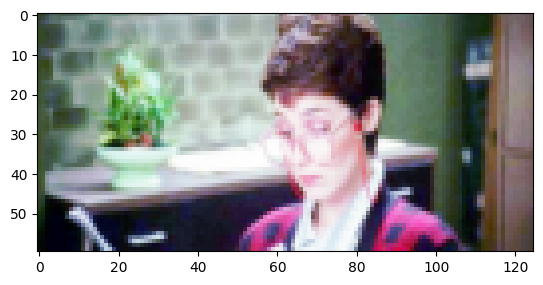

In [6]:
"""
A sanity check cell to verify the data pipeline.
It grabs a single batch from the training dataset and prints the shapes of the returned tensors (images, descriptions, etc.) to ensure everything is loaded correctly.
"""

frames, descriptions, image_target, text_target, roi1, roi2, roi_valid, roi_frame, ent_id = sp_train_dataset[np.random.randint(0,400)]

print("Description: ", descriptions.shape)
figure, ax = plt.subplots(1,1)
show_image(ax, image_target)

# Do some tests on the batches (try with batch size small)
frames, descriptions, image_target, text_target, roi1, roi2, roi_valid, roi_frame, ent_id = next(iter(train_dataloader))
print(frames.shape)
print(descriptions.shape)

In [7]:
# @title Variables and initial setup
"""
Global setup:
- Sets the computation device (CUDA/CPU).
- Defines hyperparameters: `N_EPOCHS`, `emb_dim`, `latent_dim`, etc.
"""

torch.cuda.empty_cache()
gc.collect()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_EPOCHS = 10
emb_dim = 16
latent_dim = 16
num_layers = 1
dropout = True

In [8]:
# @title Initializing the NLP models
"""
1. Instantiates the `EncoderLSTM`, `DecoderLSTM`, and `Seq2SeqLSTM`.
2. Loads pre-trained weights from Google Drive (`text_autoencoder.pth`).
3. Freezes the text autoencoder parameters to keep them fixed during the main training phase.
"""

encoder = EncoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device)
decoder = DecoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device)
text_autoencoder = Seq2SeqLSTM(encoder, decoder).to(device)
text_autoencoder, _, _, _ = load_checkpoint_from_drive(text_autoencoder, None, filename='text_autoencoder.pth')

total_params = sum(p.numel() for p in text_autoencoder.parameters())
print(f"Total parameters (Not trainable): {total_params}")
# Deactivating training from this model for efficiency (although not ideal)
for param in text_autoencoder.parameters():
        param.requires_grad = False

Checkpoint loaded from: /content/gdrive/MyDrive/DL_Checkpoints/text_autoencoder.pth (epoch 15)
Total parameters (Not trainable): 1499930


In [9]:
# @title Initializing visual models
"""
1. Instantiates the `VisualAutoencoder`.
2. Applies the custom weight initialization.
"""

visual_autoencoder = VisualAutoencoder(latent_dim=16)
visual_autoencoder.apply(init_weights)

total_params = sum(p.numel() for p in visual_autoencoder.parameters() if p.requires_grad)
print(f"Total trainable parameters in visual autoencoder: {total_params}")

Total trainable parameters in visual autoencoder: 503539


In [10]:
# @title Initialize the main architecture
"""
Instantiates the full `SequencePredictor` model, wiring together the visual encoder, text encoder, and the sequence modeling components.
Prints the total number of parameters.
"""

# We put all the sizes the same, not ideal as well
sequence_predictor = SequencePredictor(visual_autoencoder, text_autoencoder, latent_dim, latent_dim)
sequence_predictor.to(device)

# # Print number of trainable parameters
total_params = sum(p.numel() for p in sequence_predictor.parameters() if p.requires_grad)
print(f"Total trainable parameters in the whole model: {total_params}")

# Print model size
total_params = sum(p.numel() for p in sequence_predictor.parameters())
print(f"Total parameters: {total_params}")

Total trainable parameters in the whole model: 507028
Total parameters: 2006958


## 3.2 Training loops

In [ ]:
# @title Training loop

losses = train_model(
    model=sequence_predictor,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    tokenizer=tokenizer,
    device=device,
    n_epochs=10,
    log_file='/content/gdrive/MyDrive/DL_Checkpoints/baseline_training_log.txt',
    checkpoint_name='baseline_checkpoint.pth'
)

In [ ]:
# =============================================================================
# Experiment 1: ResNet Visual Encoder + GRU (baseline sequence model)
# =============================================================================

resnet_encoder = ResNetVisualEncoder(latent_dim=16).to(device)

exp1_model = ModifiedSequencePredictor(resnet_encoder, text_autoencoder, latent_dim, latent_dim)
exp1_model.to(device)

total_params = sum(p.numel() for p in exp1_model.parameters() if p.requires_grad)
print(f"Experiment 1 trainable parameters: {total_params}")

exp1_losses = train_model(
    model=exp1_model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    tokenizer=tokenizer,
    device=device,
    n_epochs=10,
    log_file='/content/gdrive/MyDrive/DL_Checkpoints/experiment1_training_log.txt',
    checkpoint_name='experiment1_checkpoint.pth'
)

In [ ]:
# =============================================================================
# Experiment 1b: ResNet + GRU with lower learning rate 10 epochs
# =============================================================================

resnet_encoder_exp1b = ResNetVisualEncoder(latent_dim=16).to(device)

exp1b_model = ModifiedSequencePredictor(resnet_encoder_exp1b, text_autoencoder, latent_dim, latent_dim, use_bilstm=False)
exp1b_model.to(device)

exp1b_losses = train_model(
    model=exp1b_model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    tokenizer=tokenizer,
    device=device,
    n_epochs=10,
    lr=0.0001,
    log_file='/content/gdrive/MyDrive/DL_Checkpoints/experiment1b_training_log.txt',
    checkpoint_name='experiment1b_checkpoint.pth'
)

In [ ]:
# =============================================================================
# Experiment 1c: ResNet + GRU, lr=0.0001, 20 epochs
# =============================================================================

resnet_encoder_exp1c = ResNetVisualEncoder(latent_dim=16).to(device)

exp1c_model = ModifiedSequencePredictor(resnet_encoder_exp1c, text_autoencoder, latent_dim, latent_dim, use_bilstm=False)
exp1c_model.to(device)

exp1c_losses = train_model(
    model=exp1c_model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    tokenizer=tokenizer,
    device=device,
    n_epochs=20,
    lr=0.0001,
    log_file='/content/gdrive/MyDrive/DL_Checkpoints/experiment1c_training_log.txt',
    checkpoint_name='experiment1c_checkpoint.pth'
)

In [ ]:
# =============================================================================
# Experiment 3: ResNet + GRU with larger hidden dim
# =============================================================================

resnet_encoder_exp3 = ResNetVisualEncoder(latent_dim=16).to(device)

exp3_model = ModifiedSequencePredictor(resnet_encoder_exp3, text_autoencoder, latent_dim=16, gru_hidden_dim=64, use_bilstm=False)
exp3_model.to(device)

exp3_losses = train_model(
    model=exp3_model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    tokenizer=tokenizer,
    device=device,
    n_epochs=10,
    lr=0.001,
    log_file='/content/gdrive/MyDrive/DL_Checkpoints/experiment3_training_log.txt',
    checkpoint_name='experiment3_checkpoint.pth'
)

In [ ]:
# =============================================================================
# Experiment 2: ResNet Visual Encoder + Bidirectional LSTM
# =============================================================================

resnet_encoder_exp2 = ResNetVisualEncoder(latent_dim=16).to(device)

exp2_model = ModifiedSequencePredictor(resnet_encoder_exp2, text_autoencoder, latent_dim, latent_dim, use_bilstm=True)
exp2_model.to(device)

total_params = sum(p.numel() for p in exp2_model.parameters() if p.requires_grad)
print(f"Experiment 2 trainable parameters: {total_params}")

exp2_losses = train_model(
    model=exp2_model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    tokenizer=tokenizer,
    device=device,
    n_epochs=10,
    log_file='/content/gdrive/MyDrive/DL_Checkpoints/experiment2_training_log.txt',
    checkpoint_name='experiment2_checkpoint.pth'
)

In [ ]:
# =============================================================================
# Experiment 4: ResNet + GRU with unfrozen text decoder
# =============================================================================

# I am reloading the text autoencoder weights to ensure this experiment starts from same baseline as others
text_autoencoder, _, _, _ = load_checkpoint_from_drive(text_autoencoder, None, filename='text_autoencoder.pth')
text_autoencoder.to(device)

# Freeze encoder, unfreeze decoder
for param in text_autoencoder.encoder.parameters():
    param.requires_grad = False
for param in text_autoencoder.decoder.parameters():
    param.requires_grad = True

resnet_encoder_exp4 = ResNetVisualEncoder(latent_dim=16).to(device)

exp4_model = ModifiedSequencePredictor(resnet_encoder_exp4, text_autoencoder, latent_dim, latent_dim, use_bilstm=False)
exp4_model.to(device)

total_params = sum(p.numel() for p in exp4_model.parameters() if p.requires_grad)
print(f"Experiment 4 trainable parameters: {total_params}")

exp4_losses = train_model(
    model=exp4_model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    tokenizer=tokenizer,
    device=device,
    n_epochs=10,
    lr=0.001,
    log_file='/content/gdrive/MyDrive/DL_Checkpoints/experiment4_training_log.txt',
    checkpoint_name='experiment4_checkpoint.pth'
)

In [ ]:
# =============================================================================
# Experiment 4b: ResNet + GRU, unfrozen decoder, 20 epochs
# =============================================================================

# I am reloading the text autoencoder weights to ensure this experiment starts from same baseline as others
text_autoencoder, _, _, _ = load_checkpoint_from_drive(text_autoencoder, None, filename='text_autoencoder.pth')
text_autoencoder.to(device)

# Freeze encoder, unfreeze decoder
for param in text_autoencoder.encoder.parameters():
    param.requires_grad = False
for param in text_autoencoder.decoder.parameters():
    param.requires_grad = True

resnet_encoder_exp4b = ResNetVisualEncoder(latent_dim=16).to(device)

exp4b_model = ModifiedSequencePredictor(resnet_encoder_exp4b, text_autoencoder, latent_dim, latent_dim, use_bilstm=False)
exp4b_model.to(device)

exp4b_losses = train_model(
    model=exp4b_model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    tokenizer=tokenizer,
    device=device,
    n_epochs=20,
    lr=0.001,
    log_file='/content/gdrive/MyDrive/DL_Checkpoints/experiment4b_training_log.txt',
    checkpoint_name='experiment4b_checkpoint.pth'
)

In [ ]:
# =============================================================================
# Experiment 5: ResNet + BiLSTM, unfrozen decoder, 20 epochs
# =============================================================================

# I am reloading the text autoencoder weights to ensure this experiment starts from same baseline as others
text_autoencoder, _, _, _ = load_checkpoint_from_drive(text_autoencoder, None, filename='text_autoencoder.pth')
text_autoencoder.to(device)

# Freeze encoder, unfreeze decoder
for param in text_autoencoder.encoder.parameters():
    param.requires_grad = False
for param in text_autoencoder.decoder.parameters():
    param.requires_grad = True

resnet_encoder_exp5 = ResNetVisualEncoder(latent_dim=16).to(device)

exp5_model = ModifiedSequencePredictor(resnet_encoder_exp5, text_autoencoder, latent_dim, latent_dim, use_bilstm=True)
exp5_model.to(device)

exp5_losses = train_model(
    model=exp5_model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    tokenizer=tokenizer,
    device=device,
    n_epochs=20,
    lr=0.001,
    log_file='/content/gdrive/MyDrive/DL_Checkpoints/experiment5_training_log.txt',
    checkpoint_name='experiment5_checkpoint.pth'
)

In [ ]:
# =============================================================================
# Experiment 6: ResNet (64-dim) + GRU, unfrozen decoder, 20 epochs
# =============================================================================

# I am reloading the text autoencoder weights to ensure this experiment starts from same baseline as others
text_autoencoder, _, _, _ = load_checkpoint_from_drive(text_autoencoder, None, filename='text_autoencoder.pth')
text_autoencoder.to(device)
for param in text_autoencoder.encoder.parameters():
    param.requires_grad = False
for param in text_autoencoder.decoder.parameters():
    param.requires_grad = True

# trying 64-dim instead of 16
resnet_encoder_exp6 = ResNetVisualEncoder(latent_dim=64).to(device)

exp6_model = ModifiedSequencePredictor(
    resnet_encoder_exp6, text_autoencoder,
    latent_dim=16, gru_hidden_dim=16,
    use_bilstm=False, image_latent_dim=64
).to(device)

total_params = sum(p.numel() for p in exp6_model.parameters() if p.requires_grad)
print(f"Experiment 6 trainable parameters: {total_params}")

exp6_losses = train_model(
    model=exp6_model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    tokenizer=tokenizer,
    device=device,
    n_epochs=20,
    lr=0.001,
    log_file='/content/gdrive/MyDrive/DL_Checkpoints/experiment6_training_log.txt',
    checkpoint_name='experiment6_checkpoint.pth'
)

In [ ]:
# =============================================================================
# Experiment 7: ResNet (128-dim) + GRU, unfrozen decoder, 20 epochs
# =============================================================================

# I am reloading the text autoencoder weights to ensure this experiment starts from same baseline as others
text_autoencoder, _, _, _ = load_checkpoint_from_drive(text_autoencoder, None, filename='text_autoencoder.pth')
text_autoencoder.to(device)
for param in text_autoencoder.encoder.parameters():
    param.requires_grad = False
for param in text_autoencoder.decoder.parameters():
    param.requires_grad = True

resnet_encoder_exp7 = ResNetVisualEncoder(latent_dim=128).to(device)

exp7_model = ModifiedSequencePredictor(
    resnet_encoder_exp7, text_autoencoder,
    latent_dim=16, gru_hidden_dim=16,
    use_bilstm=False, image_latent_dim=128
).to(device)

total_params = sum(p.numel() for p in exp7_model.parameters() if p.requires_grad)
print(f"Experiment 7 trainable parameters: {total_params}")

exp7_losses = train_model(
    model=exp7_model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    tokenizer=tokenizer,
    device=device,
    n_epochs=20,
    lr=0.001,
    log_file='/content/gdrive/MyDrive/DL_Checkpoints/experiment7_training_log.txt',
    checkpoint_name='experiment7_checkpoint.pth'
)

In [ ]:
# @title Example text reconstruction task
"""
EXPLANATION:
A standalone training loop for the text autoencoder.
This is used if you want to pre-train or fine-tune the text module separately before the main task.
"""

# Don't forget to unfreeze the model!
# We need to unfreeze the parameters so we can calculate gradients
for param in text_autoencoder.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(text_autoencoder.parameters(), lr=0.001)

loss_fn = nn.CrossEntropyLoss(ignore_index=tokenizer.convert_tokens_to_ids(tokenizer.pad_token))
N_EPOCHS = 5

for epoch in range(N_EPOCHS):
    text_autoencoder.train()
    epoch_loss = 0
    for description in text_dataloader:
        # Move the "sentences" to device
        input_ids = tokenizer(description, return_tensors="pt",  padding=True, truncation=True).input_ids
        input_ids = input_ids.to(device)

        # zero the grad, then forward pass
        optimizer.zero_grad()
        outputs = text_autoencoder(input_ids, input_ids)
        # compute the loss: compare 3D logits to 2D targets
        loss = loss_fn(outputs.reshape(-1, tokenizer.vocab_size), input_ids[:, 1:].reshape(-1))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{N_EPOCHS}; Avg loss {epoch_loss/len(text_dataloader)}; Latest loss {loss.item()}")
    torch.save(text_autoencoder.state_dict(), f"seq2seq-epoch-{epoch+1}.pth")

# # saving checkpoint to drive
save_checkpoint_to_drive(text_autoencoder, optimizer, 3*N_EPOCHS, loss, filename = "text_autoencoder.pth")

In [ ]:
# @title Image reonstruction task
"""
A placeholder for the visual autoencoder pre-training loop.
Similar to the text task, this would be used to train the visual components in isolation.
"""

# To-Do: Use previous labs if you want to pretrain your visual encoder

In [15]:
!pip install pytorch-msssim nltk
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from pytorch_msssim import ssim
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [13]:
# Now I will be running the trained model on the test sets to compute all metrics.

def evaluate_on_test(model, test_dataloader, tokenizer, device):
    criterion_l1 = nn.L1Loss()
    criterion_mse = nn.MSELoss()
    criterion_text = nn.CrossEntropyLoss(
        ignore_index=tokenizer.convert_tokens_to_ids(tokenizer.pad_token)
    )

    total_l1 = 0.0
    total_mse = 0.0
    total_ssim = 0.0
    total_ce = 0.0
    total_bleu = 0.0
    n_batches = 0
    n_samples = 0

    model.eval()
    with torch.no_grad():
        for (frames, descriptions, image_target, text_target,
             roi1, roi2, roi_valid, roi_frame, ent_id) in test_dataloader:

            frames = frames.to(device)
            descriptions = descriptions.to(device)
            image_target = image_target.to(device)
            text_target = text_target.to(device)

            # get predictions
            pred_image, pred_context, pred_text_logits, h0, c0, _, _ = model(
                frames, descriptions, text_target
            )

            # for the image metrics
            total_l1 += criterion_l1(pred_image, image_target).item()
            total_mse += criterion_mse(pred_image, image_target).item()
            total_ssim += ssim(pred_image, image_target, data_range=1.0, size_average=True).item()

            # cross entropy
            pred_flat = pred_text_logits.reshape(-1, tokenizer.vocab_size)
            target_labels = text_target.squeeze(1)[:, 1:]
            target_flat = target_labels.reshape(-1)
            total_ce += criterion_text(pred_flat, target_flat).item()

            # calculating the BLEU score also using smoothing to prevent errors and 0 response
            pred_tokens = pred_text_logits.argmax(dim=-1)
            smooth = SmoothingFunction().method1
            for i in range(pred_tokens.size(0)):
                pred_words = tokenizer.decode(pred_tokens[i], skip_special_tokens=True).split()
                target_words = tokenizer.decode(target_labels[i], skip_special_tokens=True).split()

                if len(target_words) > 0 and len(pred_words) > 0:
                    total_bleu += sentence_bleu([target_words], pred_words, smoothing_function=smooth)

                n_samples += 1

            n_batches += 1

    results = {
        'L1': total_l1 / n_batches,
        'MSE': total_mse / n_batches,
        'SSIM': total_ssim / n_batches,
        'CrossEntropy': total_ce / n_batches,
        'BLEU': total_bleu / n_samples,
    }

    print(f"  L1 Loss:       {results['L1']:.4f}")
    print(f"  MSE Loss:      {results['MSE']:.4f}")
    print(f"  SSIM:          {results['SSIM']:.4f}")
    print(f"  CrossEntropy:  {results['CrossEntropy']:.4f}")
    print(f"  BLEU:          {results['BLEU']:.4f}")

    return results

In [16]:
# =============================================================================
# Test Evaluation: Baseline (CNN + GRU)
# =============================================================================
print("=== Running Baseline (CNN + GRU) ===")

# recreating the architecture as baseline
visual_autoencoder_eval = VisualAutoencoder(latent_dim=16).to(device)
visual_autoencoder_eval.apply(init_weights)

text_eval, _, _, _ = load_checkpoint_from_drive(
    Seq2SeqLSTM(
        EncoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device),
        DecoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device)
    ).to(device),
    None, filename='text_autoencoder.pth'
)
for param in text_eval.parameters():
    param.requires_grad = False

baseline_eval = SequencePredictor(visual_autoencoder_eval, text_eval, latent_dim, latent_dim).to(device)
baseline_eval, _, _, _ = load_checkpoint_from_drive(baseline_eval, None, filename='baseline_checkpoint.pth')

baseline_results = evaluate_on_test(baseline_eval, test_dataloader, tokenizer, device)

=== Running Baseline (CNN + GRU) ===
Checkpoint loaded from: /content/gdrive/MyDrive/DL_Checkpoints/text_autoencoder.pth (epoch 15)
Checkpoint loaded from: /content/gdrive/MyDrive/DL_Checkpoints/baseline_checkpoint.pth (epoch 9)
  L1 Loss:       0.2413
  MSE Loss:      0.0790
  SSIM:          0.1532
  CrossEntropy:  3.8918
  BLEU:          0.0310


In [17]:
# =============================================================================
# Test Evaluation: Experiment 1 (ResNet + GRU)
# =============================================================================
print("=== Running Experiment 1 (ResNet + GRU) ===")

exp1_eval = ModifiedSequencePredictor(
    ResNetVisualEncoder(latent_dim=16).to(device),
    text_eval, latent_dim, latent_dim, use_bilstm=False
).to(device)
exp1_eval, _, _, _ = load_checkpoint_from_drive(exp1_eval, None, filename='experiment1_checkpoint.pth')

exp1_results = evaluate_on_test(exp1_eval, test_dataloader, tokenizer, device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


=== Running Experiment 1 (ResNet + GRU) ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 213MB/s]


Checkpoint loaded from: /content/gdrive/MyDrive/DL_Checkpoints/experiment1_checkpoint.pth (epoch 9)
  L1 Loss:       0.2413
  MSE Loss:      0.0788
  SSIM:          0.1533
  CrossEntropy:  3.8296
  BLEU:          0.0317


In [18]:
# =============================================================================
# Test Evaluation: Experiment 2 (ResNet + BiLSTM)
# =============================================================================
print("=== Running Experiment 2 (ResNet + BiLSTM) ===")

exp2_eval = ModifiedSequencePredictor(
    ResNetVisualEncoder(latent_dim=16).to(device),
    text_eval, latent_dim, latent_dim, use_bilstm=True
).to(device)
exp2_eval, _, _, _ = load_checkpoint_from_drive(exp2_eval, None, filename='experiment2_checkpoint.pth')

exp2_results = evaluate_on_test(exp2_eval, test_dataloader, tokenizer, device)

=== Running Experiment 2 (ResNet + BiLSTM) ===
Checkpoint loaded from: /content/gdrive/MyDrive/DL_Checkpoints/experiment2_checkpoint.pth (epoch 9)
  L1 Loss:       0.2414
  MSE Loss:      0.0788
  SSIM:          0.1534
  CrossEntropy:  3.8307
  BLEU:          0.0309


In [19]:
# =============================================================================
# Test Evaluation: Experiment 4b (ResNet + GRU, unfrozen decoder, 20 epochs)
# =============================================================================
print("=== Running Experiment 4b (ResNet + GRU, unfrozen decoder) ===")

text_unfrozen, _, _, _ = load_checkpoint_from_drive(
    Seq2SeqLSTM(
        EncoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device),
        DecoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device)
    ).to(device),
    None, filename='text_autoencoder.pth'
)
for param in text_unfrozen.encoder.parameters():
    param.requires_grad = False

exp4b_eval = ModifiedSequencePredictor(
    ResNetVisualEncoder(latent_dim=16).to(device),
    text_unfrozen, latent_dim, latent_dim, use_bilstm=False
).to(device)
exp4b_eval, _, _, _ = load_checkpoint_from_drive(exp4b_eval, None, filename='experiment4b_checkpoint.pth')

exp4b_results = evaluate_on_test(exp4b_eval, test_dataloader, tokenizer, device)

=== Running Experiment 4b (ResNet + GRU, unfrozen decoder) ===
Checkpoint loaded from: /content/gdrive/MyDrive/DL_Checkpoints/text_autoencoder.pth (epoch 15)
Checkpoint loaded from: /content/gdrive/MyDrive/DL_Checkpoints/experiment4b_checkpoint.pth (epoch 19)
  L1 Loss:       0.2412
  MSE Loss:      0.0789
  SSIM:          0.1537
  CrossEntropy:  3.7479
  BLEU:          0.0367


In [20]:
# =============================================================================
# Test Evaluation: Experiment 5 (ResNet + BiLSTM, unfrozen decoder, 20 epochs)
# =============================================================================
print("=== Running Experiment 5 (ResNet + BiLSTM, unfrozen decoder) ===")

text_unfrozen2, _, _, _ = load_checkpoint_from_drive(
    Seq2SeqLSTM(
        EncoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device),
        DecoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device)
    ).to(device),
    None, filename='text_autoencoder.pth'
)
for param in text_unfrozen2.encoder.parameters():
    param.requires_grad = False

exp5_eval = ModifiedSequencePredictor(
    ResNetVisualEncoder(latent_dim=16).to(device),
    text_unfrozen2, latent_dim, latent_dim, use_bilstm=True
).to(device)
exp5_eval, _, _, _ = load_checkpoint_from_drive(exp5_eval, None, filename='experiment5_checkpoint.pth')

exp5_results = evaluate_on_test(exp5_eval, test_dataloader, tokenizer, device)

=== Running Experiment 5 (ResNet + BiLSTM, unfrozen decoder) ===
Checkpoint loaded from: /content/gdrive/MyDrive/DL_Checkpoints/text_autoencoder.pth (epoch 15)
Checkpoint loaded from: /content/gdrive/MyDrive/DL_Checkpoints/experiment5_checkpoint.pth (epoch 19)
  L1 Loss:       0.2413
  MSE Loss:      0.0789
  SSIM:          0.1536
  CrossEntropy:  3.7470
  BLEU:          0.0373


In [21]:
# =============================================================================
# Test Evaluation: Experiment 6 (ResNet 64-dim + GRU, unfrozen decoder)
# =============================================================================
print("=== Running Experiment 6 (ResNet 64-dim + GRU, unfrozen decoder) ===")

text_exp6, _, _, _ = load_checkpoint_from_drive(
    Seq2SeqLSTM(
        EncoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device),
        DecoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device)
    ).to(device),
    None, filename='text_autoencoder.pth'
)
for param in text_exp6.encoder.parameters():
    param.requires_grad = False

exp6_eval = ModifiedSequencePredictor(
    ResNetVisualEncoder(latent_dim=64).to(device),
    text_exp6, latent_dim=16, gru_hidden_dim=16,
    use_bilstm=False, image_latent_dim=64
).to(device)
exp6_eval, _, _, _ = load_checkpoint_from_drive(exp6_eval, None, filename='experiment6_checkpoint.pth')

exp6_results = evaluate_on_test(exp6_eval, test_dataloader, tokenizer, device)

=== Running Experiment 6 (ResNet 64-dim + GRU, unfrozen decoder) ===
Checkpoint loaded from: /content/gdrive/MyDrive/DL_Checkpoints/text_autoencoder.pth (epoch 15)
Checkpoint loaded from: /content/gdrive/MyDrive/DL_Checkpoints/experiment6_checkpoint.pth (epoch 19)
  L1 Loss:       0.2413
  MSE Loss:      0.0789
  SSIM:          0.1538
  CrossEntropy:  3.7512
  BLEU:          0.0422


In [22]:
# =============================================================================
# Summary Table
# =============================================================================
all_results = {
    'Baseline (CNN+GRU)': baseline_results,
    'Exp1 (ResNet+GRU)': exp1_results,
    'Exp2 (ResNet+BiLSTM)': exp2_results,
    'Exp4b (ResNet+GRU+Unfrozen)': exp4b_results,
    'Exp5 (ResNet+BiLSTM+Unfrozen)': exp5_results,
    'Exp6 (64-dim+Unfrozen)': exp6_results
}

print(f"{'Model':<32} {'L1':>8} {'MSE':>8} {'SSIM':>8} {'CE':>8} {'BLEU':>8}")
print("-" * 76)
for name, r in all_results.items():
    print(f"{name:<32} {r['L1']:>8.4f} {r['MSE']:>8.4f} {r['SSIM']:>8.4f} {r['CrossEntropy']:>8.4f} {r['BLEU']:>8.4f}")

Model                                  L1      MSE     SSIM       CE     BLEU
----------------------------------------------------------------------------
Baseline (CNN+GRU)                 0.2413   0.0790   0.1532   3.8918   0.0310
Exp1 (ResNet+GRU)                  0.2413   0.0788   0.1533   3.8296   0.0317
Exp2 (ResNet+BiLSTM)               0.2414   0.0788   0.1534   3.8307   0.0309
Exp4b (ResNet+GRU+Unfrozen)        0.2412   0.0789   0.1537   3.7479   0.0367
Exp5 (ResNet+BiLSTM+Unfrozen)      0.2413   0.0789   0.1536   3.7470   0.0373
Exp6 (64-dim+Unfrozen)             0.2413   0.0789   0.1538   3.7512   0.0422


In [ ]:
!pip install grad-cam

In [12]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

In [24]:
# See baseline structure
print("=== the baseline CNN layers ===")
print(baseline_eval.image_encoder.content_backbone.encoder_conv)

print("\n=== the resnet layers ===")
print(exp6_eval.image_encoder.features[-1])

=== the baseline CNN layers ===
Sequential(
  (0): Conv2d(3, 16, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (1): GroupNorm(8, 16, eps=1e-05, affine=True)
  (2): LeakyReLU(negative_slope=0.1)
  (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (4): GroupNorm(8, 32, eps=1e-05, affine=True)
  (5): LeakyReLU(negative_slope=0.1)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (7): GroupNorm(8, 64, eps=1e-05, affine=True)
  (8): LeakyReLU(negative_slope=0.1)
)

=== the resnet layers ===
Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequ

In [26]:
# using a custom target since our model outputs latent vectors, and not class scores
class CustomTarget:
    def __call__(self, model_output):
        return model_output.sum(dim=-1)

# generates a grad CAM heatmap for a single image
def generate_gradcam(model_encoder, target_layer, input_image, device):
    cam = GradCAM(model=model_encoder, target_layers=[target_layer])
    input_tensor = input_image.unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_tensor, targets=[CustomTarget()])
    return grayscale_cam[0]

# show grad CAm comparison to compare the baseline CNN vs the ResNet on sample frames
def show_gradcam_comparison(baseline_model, resnet_model, test_dataloader, device, num_samples=3):

    # first I'm retreiving a batch of test stories
    frames, descriptions, _, _, _, _, _, _, _ = next(iter(test_dataloader))

    # retrieve target layers, based on our examination in the cell above
    baseline_target = baseline_model.image_encoder.content_backbone.encoder_conv[6]
    resnet_target = resnet_model.image_encoder.features[-1][-1].conv2

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

    for i in range(num_samples):
        # retrieve first story, frame i
        sample_image = frames[0, i]

        # I am getting the original image and also ensuring it is in valid range
        rgb_image = sample_image.permute(1, 2, 0).cpu().numpy()
        rgb_image = np.clip(rgb_image, 0, 1)

        # baseline Grad CAM
        baseline_cam = generate_gradcam(
            baseline_model.image_encoder.content_backbone,
            baseline_target,
            sample_image, device
        )
        baseline_overlay = show_cam_on_image(rgb_image, baseline_cam, use_rgb=True)

        # ResNet Grad CAM
        resnet_cam = generate_gradcam(
            resnet_model.image_encoder,
            resnet_target,
            sample_image, device
        )
        resnet_overlay = show_cam_on_image(rgb_image, resnet_cam, use_rgb=True)

        # finally we plot
        axes[i, 0].imshow(rgb_image)
        axes[i, 0].set_title(f'Frame {i+1}: Original')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(baseline_overlay)
        axes[i, 1].set_title(f'Frame {i+1}: Baseline CNN')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(resnet_overlay)
        axes[i, 2].set_title(f'Frame {i+1}: ResNet18')
        axes[i, 2].axis('off')

    plt.suptitle('The Grad CAM: Where each model focuses on', fontsize=16)
    plt.tight_layout()
    plt.savefig('/content/gdrive/MyDrive/DL_Checkpoints/gradcam_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to gradcam_comparison.png")

In [ ]:
show_gradcam_comparison(baseline_eval, exp6_eval, test_dataloader, device, num_samples=3)

In [29]:
import re

# here we read each created log file to extract the loss
def parse_training_log(filepath):
    losses = []
    with open(filepath, 'r') as f:
        for line in f:
            match = re.search(r'Loss: ([\d.]+)', line)
            if match:
                losses.append(float(match.group(1)))
    return losses

# loading all logs
log_dir = '/content/gdrive/MyDrive/DL_Checkpoints'

baseline_losses = parse_training_log(f'{log_dir}/baseline_training_log.txt')
exp1_losses = parse_training_log(f'{log_dir}/experiment1_training_log.txt')
exp2_losses = parse_training_log(f'{log_dir}/experiment2_training_log.txt')
exp4b_losses = parse_training_log(f'{log_dir}/experiment4b_training_log.txt')
exp6_losses = parse_training_log(f'{log_dir}/experiment6_training_log.txt')

print(f"Baseline: {len(baseline_losses)} epochs, final: {baseline_losses[-1]:.4f}")
print(f"Exp 1:    {len(exp1_losses)} epochs, final: {exp1_losses[-1]:.4f}")
print(f"Exp 2:    {len(exp2_losses)} epochs, final: {exp2_losses[-1]:.4f}")
print(f"Exp 4b:   {len(exp4b_losses)} epochs, final: {exp4b_losses[-1]:.4f}")
print(f"Exp 6:    {len(exp6_losses)} epochs, final: {exp6_losses[-1]:.4f}")

Baseline: 10 epochs, final: 4.1702
Exp 1:    10 epochs, final: 4.0962
Exp 2:    10 epochs, final: 4.1102
Exp 4b:   20 epochs, final: 3.7888
Exp 6:    20 epochs, final: 3.7020


In [ ]:
#now on to plotting the training loss curves
# i am selecting a few of the experiments to highlight the difference

plt.figure(figsize=(12, 7))

plt.plot(range(1, 11), baseline_losses, 'o-', label='Baseline (CNN + GRU)', linewidth=2)
plt.plot(range(1, 11), exp1_losses, 's-', label='ResNet + GRU', linewidth=2)
plt.plot(range(1, 11), exp2_losses, '^-', label='ResNet + BiLSTM', linewidth=2)
plt.plot(range(1, 21), exp4b_losses, 'D-', label='ResNet + GRU + Unfrozen Decoder', linewidth=2)
plt.plot(range(1, 21), exp6_losses, 'v-', label='ResNet (64-dim) + GRU + Unfrozen Decoder', linewidth=2)

plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Training Loss', fontsize=13)
plt.title('Training Loss Comparison Across Select Experiments', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('/content/gdrive/MyDrive/DL_Checkpoints/training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved training_loss_curves.png")

In [ ]:
# test set metrics bar chart

models = ['Baseline', 'ResNet\n+GRU', 'ResNet\n+BiLSTM', 'Unfrozen\nDecoder', '64-dim\n+Unfrozen']

l1_scores = [0.2413, 0.2413, 0.2414, 0.2412, 0.2413]
mse_scores = [0.0790, 0.0788, 0.0788, 0.0789, 0.0789]
ssim_scores = [0.1532, 0.1533, 0.1534, 0.1537, 0.1538]
bleu_scores = [0.0310, 0.0317, 0.0309, 0.0367, 0.0422]
ce_scores = [3.8918, 3.8296, 3.8307, 3.7479, 3.7512]

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

# L1
bars = axes[0].bar(models, l1_scores, color=colors)
axes[0].set_title('L1 Loss', fontsize=12)
axes[0].set_ylim(0.235, 0.245)
for bar, val in zip(bars, l1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', fontsize=9)

# MSE
bars = axes[1].bar(models, mse_scores, color=colors)
axes[1].set_title('MSE Loss', fontsize=12)
axes[1].set_ylim(0.076, 0.082)
for bar, val in zip(bars, mse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', fontsize=9)

# SSIM
bars = axes[2].bar(models, ssim_scores, color=colors)
axes[2].set_title('SSIM', fontsize=12)
axes[2].set_ylim(0.148, 0.158)
for bar, val in zip(bars, ssim_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', fontsize=9)

# Cross Entropy
bars = axes[3].bar(models, ce_scores, color=colors)
axes[3].set_title('Cross Entropy', fontsize=12)
axes[3].set_ylim(3.6, 4.0)
for bar, val in zip(bars, ce_scores):
    axes[3].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=9)

# BLEU
bars = axes[4].bar(models, bleu_scores, color=colors)
axes[4].set_title('BLEU Score', fontsize=12)
axes[4].set_ylim(0, 0.05)
for bar, val in zip(bars, bleu_scores):
    axes[4].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=9)

plt.suptitle('Test Set Metrics Comparison Across All Experiments', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('/content/gdrive/MyDrive/DL_Checkpoints/all_test_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved all_test_metrics.png")

In [39]:
# =============================================================================
# Comparison Table for: Training Loss and Test Set Metrics
# =============================================================================

print("=" * 100)
print(f"{'Model':<35} {'Train Loss':>12} {'Test L1':>10} {'Test MSE':>10} {'Test SSIM':>10} {'Test CE':>10} {'Test BLEU':>10}")
print("=" * 100)

table_data = [
    ('Baseline (CNN + GRU)',           baseline_losses[-1], 0.2413, 0.0790, 0.1532, 3.8918, 0.0310),
    ('Exp1: ResNet + GRU',            exp1_losses[-1],     0.2413, 0.0788, 0.1533, 3.8296, 0.0317),
    ('Exp2: ResNet + BiLSTM',         exp2_losses[-1],     0.2414, 0.0788, 0.1534, 3.8307, 0.0309),
    ('Exp4b: Unfrozen Decoder',       exp4b_losses[-1],    0.2412, 0.0789, 0.1537, 3.7479, 0.0367),
    ('Exp6: 64-dim + Unfrozen',       exp6_losses[-1],     0.2413, 0.0789, 0.1538, 3.7512, 0.0422),
]

for name, train, l1, mse, ssim_val, ce, bleu in table_data:
    print(f"{name:<35} {train:>12.4f} {l1:>10.4f} {mse:>10.4f} {ssim_val:>10.4f} {ce:>10.4f} {bleu:>10.4f}")

print("=" * 100)

Model                                 Train Loss    Test L1   Test MSE  Test SSIM    Test CE  Test BLEU
Baseline (CNN + GRU)                      4.1702     0.2413     0.0790     0.1532     3.8918     0.0310
Exp1: ResNet + GRU                        4.0962     0.2413     0.0788     0.1533     3.8296     0.0317
Exp2: ResNet + BiLSTM                     4.1102     0.2414     0.0788     0.1534     3.8307     0.0309
Exp4b: Unfrozen Decoder                   3.7888     0.2412     0.0789     0.1537     3.7479     0.0367
Exp6: 64-dim + Unfrozen                   3.7020     0.2413     0.0789     0.1538     3.7512     0.0422


In [ ]:
# =============================================================================
# Attention Weight Visualization
# -> this shows which frame was relevant to the model when predicting the
# last frame
# =============================================================================

def get_attention_weights(model, test_dataloader, device, num_samples=5):
    # first we extract attention weights
    model.eval()
    all_weights = []

    # set up hook to capture weight
    captured_weights = []

    def hook_setup(module, input, output):
        # the attention module uses softmax to get the weights, and we need to capture the weights
        #  before the batch matrix multiplication is done
        returned_value = module.attn(input[0] ).squeeze(2)
        weights = module.softmax(returned_value)
        captured_weights.append(weights.detach().cpu())

    # next we register the hook on the attention module
    hook = model.attention.register_forward_hook(hook_setup)

    with torch.no_grad():
        for idx, (frames, descriptions, image_target, text_target,
                  roi1, roi2, roi_valid, roi_frame, ent_id) in enumerate(test_dataloader):
            if idx >= num_samples:
                break

            frames = frames.to(device)
            descriptions = descriptions.to(device)
            text_target = text_target.to(device)

            model(frames, descriptions, text_target)

    hook.remove()

    # combine all the captured weights
    weights = torch.cat(captured_weights, dim=0)
    return weights.numpy()

# now we retrieve the weights for each model
print("extracting attention weights...")
baseline_weights = get_attention_weights(baseline_eval, test_dataloader, device)
exp1_weights = get_attention_weights(exp1_eval, test_dataloader, device)
exp6_weights = get_attention_weights(exp6_eval, test_dataloader, device)

# finally we plot the average attention weights
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
frame_labels = ['Frame 1', 'Frame 2', 'Frame 3', 'Frame 4']

for ax, weights, title in zip(axes,
    [baseline_weights, exp1_weights, exp6_weights],
    ['Baseline (CNN + GRU)', 'ResNet + GRU', 'ResNet (64-dim) + Unfrozen']):

    avg_weights = weights.mean(axis=0)
    bars = ax.bar(frame_labels, avg_weights, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Attention Weight', fontsize=11)
    ax.set_ylim(0, 0.5)
    for bar, val in zip(bars, avg_weights):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=11)

plt.suptitle('Average Attention Weights: Which frames matter most for prediction?', fontsize=15)
plt.tight_layout()
plt.savefig('/content/gdrive/MyDrive/DL_Checkpoints/attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved attention_weights.png")